# B4 — ConvNeXt V2-T + Vanilla EDL + KL

## 1. Environment

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip -q install "torch>=2.2" "torchvision>=0.17" "timm>=1.0" scikit-learn pandas numpy matplotlib tqdm thop scipy pylidc pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 104.7 MB/s eta 0:00:00


In [ ]:
import os, gc, json, math, time, random, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import timm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.stats import wilcoxon
from tqdm.auto import tqdm
from thop import profile
warnings.filterwarnings('ignore')

## 2. Paths and experiment folder structure

In [ ]:
MYDRIVE = Path("/content/drive/MyDrive")

ROOT_CANDIDATES = [MYDRIVE / "Thesis_Work/LIDC_Thesis", MYDRIVE / "LIDC_Thesis"]
THESIS_ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "LIDC/processed/arrays/images.npy").exists()),
    ROOT_CANDIDATES[0],
)
LIDC_ROOT = THESIS_ROOT / "LIDC"
PROCESSED = LIDC_ROOT / "processed"
ARRAYS = PROCESSED / "arrays"
META = PROCESSED / "metadata"
B4_ROOT = THESIS_ROOT / "experiments" / "B4_ConvNeXtV2T_Vanilla_EDL_KL"
DIRS = {
    "notebooks": B4_ROOT / "notebooks",
    "configs": B4_ROOT / "configs",
    "splits": B4_ROOT / "splits",
    "checkpoints": B4_ROOT / "checkpoints",
    "predictions": B4_ROOT / "predictions",
    "metrics": B4_ROOT / "metrics",
    "metrics_classification": B4_ROOT / "metrics/classification",
    "metrics_calibration": B4_ROOT / "metrics/calibration",
    "metrics_uncertainty": B4_ROOT / "metrics/uncertainty",
    "metrics_efficiency": B4_ROOT / "metrics/efficiency",
    "gradcam": B4_ROOT / "gradcam",
    "esm": B4_ROOT / "esm",
    "plots": B4_ROOT / "plots",
    "plots_training": B4_ROOT / "plots/training_curves",
    "plots_cm": B4_ROOT / "plots/confusion_matrices",
    "plots_roc": B4_ROOT / "plots/roc_curves",
    "plots_cal": B4_ROOT / "plots/calibration_diagrams",
    "plots_rel": B4_ROOT / "plots/reliability_diagrams",
    "plots_reject": B4_ROOT / "plots/rejection_curves",
    "logs": B4_ROOT / "logs",
    "reports": B4_ROOT / "reports",
    "ablations": B4_ROOT / "ablations",
    "xai_metrics": B4_ROOT / "metrics/xai",
}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)
print("THESIS_ROOT:", THESIS_ROOT)
print("B4_ROOT:", B4_ROOT)


THESIS_ROOT: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis
B4_ROOT: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B4_ConvNeXtV2T_Vanilla_EDL_KL


## 3. Configuration contract

### GAP FIX A — reproducibility files
Adds `configs/split_config.json` and `configs/random_seeds.json` (missing in the original B4, present in B1/B2/C1). Nothing else in CONFIG changed.


In [ ]:
CONFIG = {
    "config_id": "B4",
    "backbone": "ConvNeXt V2-T",
    "timm_model_name": "convnextv2_tiny.fcmae_ft_in1k",
    "pretrained": True,
    "uq_method": "Vanilla EDL",
    "num_classes": 3,
    "class_names": ["benign", "indeterminate", "malignant"],
    "evidence_activation": "Softplus",
    "prior_weight_C": 1.0,
    "lambda_kl": 1.0,
    "kl_anneal_epochs": 10,
    "kl_target": "Dirichlet(C*1) with target-class alpha fixed to C",
    "fold_hash_required": True,
    "pilot_config_required": True,
    "lambda_kl_source": "ASSUMPTION: plan leaves lambda_KL numeric value unspecified",
    "seed": 42,
    "n_folds": 5,
    "validation_fraction_of_trainval": 0.10,
    "image_size": 224,
    "batch_size": 32,
    "num_workers": 0,
    "max_epochs": 50,
    "early_stopping_patience": 10,
    "early_stopping_metric": "validation_brier_score",
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "eta_min": 1e-6,
    "weight_decay": 0.01,
    "betas": [0.9, 0.999],
    "ece_bins": 15,
    "epsilon": 1e-8,
    "augmentation": {
        "horizontal_flip": True,
        "vertical_flip": True,
        "rotation_degrees": 15,
        "translation_fraction": 0.10,
        "elastic_deformation": False,
        "intensity_jitter": False,
    },
    "input": "224x224x1 HU-windowed [0,1], replicated to 3 channels at runtime",
    "hu_window": [-1000, 400],
    "scope": "2D central-slice LIDC-IDRI only",
    "clinical_deployment": False,
    "external_validation": False,
    "xai_at_end": True,
    "xai_methods": ["Grad-CAM", "ESM-vacuity", "ESM-aleatoric ablation"],
    "ablation_prior_C_values": [0.5, 1.0, 2.0],
    "ablation_loss_modes": ["ece_only", "ece_plus_kl"],
}
with open(DIRS["configs"] / "B4_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
# GAP FIX A: save the split setup and the random seeds as their own files (B1, B2 and C1 already do this).
# This is the reproducibility record that shows B4 used the same patient-level folds as the other models.
with open(DIRS["configs"] / "split_config.json", "w") as f:
    json.dump(
        {
            "n_folds": CONFIG["n_folds"],
            "split_level": "patient",
            "fold_source": "preprocessing v3 fold column (reused, not re-drawn)",
            "validation_fraction_of_trainval": CONFIG[
                "validation_fraction_of_trainval"
            ],
        },
        f,
        indent=2,
    )
with open(DIRS["configs"] / "random_seeds.json", "w") as f:
    json.dump(
        {
            "global_seed": CONFIG["seed"],
            "per_fold_seed_rule": "seed + fold_number (set inside train_fold)",
        },
        f,
        indent=2,
    )
assert CONFIG["num_classes"] == 3 and CONFIG["n_folds"] == 5 and CONFIG["seed"] == 42
assert (
    CONFIG["max_epochs"] == 50
    and CONFIG["early_stopping_patience"] == 10
    and CONFIG["ece_bins"] == 15
)
assert (
    CONFIG["augmentation"]["elastic_deformation"] is False
    and CONFIG["augmentation"]["intensity_jitter"] is False
)
print(json.dumps(CONFIG, indent=2))


{
  "config_id": "B4",
  "backbone": "ConvNeXt V2-T",
  "timm_model_name": "convnextv2_tiny.fcmae_ft_in1k",
  "pretrained": true,
  "uq_method": "Vanilla EDL",
  "num_classes": 3,
  "class_names": [
    "benign",
    "indeterminate",
    "malignant"
  ],
  "evidence_activation": "Softplus",
  "prior_weight_C": 1.0,
  "lambda_kl": 1.0,
  "kl_anneal_epochs": 10,
  "kl_target": "Dirichlet(C*1) with target-class alpha fixed to C",
  "fold_hash_required": true,
  "pilot_config_required": true,
  "lambda_kl_source": "ASSUMPTION: plan leaves lambda_KL numeric value unspecified",
  "seed": 42,
  "n_folds": 5,
  "validation_fraction_of_trainval": 0.1,
  "image_size": 224,
  "batch_size": 32,
  "num_workers": 0,
  "max_epochs": 50,
  "early_stopping_patience": 10,
  "early_stopping_metric": "validation_brier_score",
  "optimizer": "AdamW",
  "learning_rate": 0.0001,
  "eta_min": 1e-06,
  "weight_decay": 0.01,
  "betas": [
    0.9,
    0.999
  ],
  "ece_bins": 15,
  "epsilon": 1e-08,
  "augmentat

## 4. Reproducibility

In [ ]:
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


seed_everything(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    "Device:",
    DEVICE,
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "",
)


Device: cuda Tesla T4


## 5. Load and validate preprocessing v3.0 artifacts (`.npy`, not PNG)

In [ ]:
required = {
    "images": ARRAYS / "images.npy",
    "labels": ARRAYS / "labels.npy",
    "variance": ARRAYS / "variance_targets.npy",
    "alignment": ARRAYS / "alignment_masks.npy",
    "patients": ARRAYS / "patient_ids.npy",
    "metadata": META / "lidc_patches_metadata.csv",
    "fold_assignments": META / "fold_assignments.csv",
    "fold_hash": META / "fold_assignments.sha256",
    "run_config": META / "preprocessing_run_config.json",
}
missing = [str(p) for p in required.values() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing preprocessing v3.0 artifacts:\n" + "\n".join(missing)
    )
images = np.load(required["images"], mmap_mode="r")
labels = np.load(required["labels"], mmap_mode="r")
variance_targets = np.load(required["variance"], mmap_mode="r")
alignment_masks = np.load(required["alignment"], mmap_mode="r")
patient_ids = np.load(required["patients"], allow_pickle=True)
metadata = pd.read_csv(required["metadata"])
fold_assignments = pd.read_csv(required["fold_assignments"])
import hashlib
actual_fold_hash = hashlib.sha256(Path(required["fold_assignments"]).read_bytes()).hexdigest()
expected_fold_hash = Path(required["fold_hash"]).read_text().strip().split()[0]
if actual_fold_hash != expected_fold_hash:
    raise RuntimeError(f"Fold assignment hash mismatch: {actual_fold_hash} != {expected_fold_hash}")
preprocessing_run_config = json.loads(Path(required["run_config"]).read_text())
PILOT_MAX_PATIENTS = preprocessing_run_config.get("PILOT_MAX_PATIENTS", None)
CONFIG["fold_assignments_sha256"] = actual_fold_hash
CONFIG["PILOT_MAX_PATIENTS"] = PILOT_MAX_PATIENTS
N = len(images)
assert images.shape == (N, 224, 224)
assert (
    len(labels)
    == len(variance_targets)
    == len(alignment_masks)
    == len(patient_ids)
    == len(metadata)
    == N
)
assert (
    np.isfinite(images).all() and float(images.min()) >= 0 and float(images.max()) <= 1
)
assert set(np.unique(labels)).issubset({0, 1, 2})
assert np.all((variance_targets >= 0) & (variance_targets <= 1))
assert np.array_equal(labels.astype(int), metadata["label_id"].to_numpy(int))
assert np.array_equal(
    patient_ids.astype(str), metadata["patient_id"].astype(str).to_numpy()
)
assert (metadata["n_radiologists"] >= 3).all() and (metadata["diameter_mm"] >= 3).all()
metadata = metadata.reset_index(drop=True)
metadata["array_index"] = np.arange(N)
metadata["label"] = labels.astype(int)
metadata["variance_target"] = variance_targets.astype(float)
metadata["alignment_mask_array"] = alignment_masks.astype(int)
print(
    "images.npy",
    images.shape,
    images.dtype,
    "range",
    float(images.min()),
    float(images.max()),
)
display(metadata.head(48))

# B1: fold_assignments.csv is the sole CV source of truth.
_fold_cols = {"patient_id", "fold"}
if not _fold_cols.issubset(fold_assignments.columns):
    raise RuntimeError(f"fold_assignments.csv must contain {_fold_cols}")
fa = fold_assignments[["patient_id","fold"]].copy()
fa["patient_id"] = fa["patient_id"].astype(str)
if fa["patient_id"].duplicated().any():
    raise RuntimeError("fold_assignments.csv has duplicate patient_id rows.")
metadata["patient_id"] = metadata["patient_id"].astype(str)
if "fold" in metadata.columns:
    metadata = metadata.drop(columns=["fold"])
metadata = metadata.merge(fa, on="patient_id", how="left", validate="many_to_one")
if metadata["fold"].isna().any():
    raise RuntimeError("Some preprocessing rows have no patient fold assignment.")
metadata["fold"] = metadata["fold"].astype(int)


images.npy (48, 224, 224) float32 range 0.0 1.0


,array_index,nodule_id,patient_id,scan_db_id,series_instance_uid,label_name,label_id,label_name_sensitivity,label_id_sensitivity,malignancy_scores,...,central_slice_k,source_pixel_spacing_mm,target_pixel_spacing_mm,field_of_view_mm,output_size_px,pilot_included,fold,label,variance_target,alignment_mask_array
0,0,LIDC-IDRI-0001_S12_N000,LIDC-IDRI-0001,12,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,malignant,2,malignant,2,5|5|5|4,...,89,0.703125,1.0,64.0,224,True,2,2,0.046875,1
1,1,LIDC-IDRI-0003_S14_N001,LIDC-IDRI-0003,14,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,malignant,2,malignant,2,5|5|3|4,...,76,0.820312,1.0,64.0,224,True,2,2,0.171875,1
2,2,LIDC-IDRI-0003_S14_N002,LIDC-IDRI-0003,14,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,indeterminate,1,malignant,2,4|4|3|2,...,83,0.820312,1.0,64.0,224,True,2,1,0.171875,1
3,3,LIDC-IDRI-0003_S14_N003,LIDC-IDRI-0003,14,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,indeterminate,1,malignant,2,4|5|3|2,...,84,0.820312,1.0,64.0,224,True,2,1,0.312500,1
4,4,LIDC-IDRI-0004_S15_N000,LIDC-IDRI-0004,15,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,benign,0,benign,0,2|1|1|1,...,76,0.822266,1.0,64.0,224,True,1,0,0.046875,1
5,5,LIDC-IDRI-0005_S16_N000,LIDC-IDRI-0005,16,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,indeterminate,1,indeterminate,1,3|3|3|2,...,77,0.664062,1.0,64.0,224,True,4,1,0.046875,1
6,6,LIDC-IDRI-0005_S16_N001,LIDC-IDRI-0005,16,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,indeterminate,1,indeterminate,1,3|3|3|2,...,80,0.664062,1.0,64.0,224,True,4,1,0.046875,1
7,7,LIDC-IDRI-0006_S17_N003,LIDC-IDRI-0006,17,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,indeterminate,1,indeterminate,1,3|4|3|2,...,84,0.625000,1.0,64.0,224,True,4,1,0.125000,1
8,8,LIDC-IDRI-0007_S18_N000,LIDC-IDRI-0007,18,1.3.6.1.4.1.14519.5.2.1.6279.6001.272348349298...,malignant,2,malignant,2,5|5|5|4,...,109,0.781250,1.0,64.0,224,True,5,2,0.046875,1
9,9,LIDC-IDRI-0008_S19_N000,LIDC-IDRI-0008,19,1.3.6.1.4.1.14519.5.2.1.6279.6001.774060103415...,indeterminate,1,indeterminate,1,3|3|2,...,71,0.781250,1.0,64.0,224,True,3,1,0.055556,1


## 6. Reuse preprocessing patient-level folds; create 10% patient-level validation split

In [ ]:
if "fold" not in metadata.columns or not set(metadata["fold"].unique()).issubset(
    {1, 2, 3, 4, 5}
):
    raise ValueError("Expected preprocessing fold assignments 1..5 in metadata.")
assert (
    metadata.groupby("patient_id")["fold"].nunique() == 1
).all(), "Patient leakage in preprocessing folds."


def split_fold(df, test_fold):
    """Locked outer test fold + deterministic patient-level stratified validation.
    """
    required={"patient_id","label","fold"}
    missing=required-set(df.columns)
    if missing:
        raise RuntimeError(
            f"B4 metadata contract mismatch: missing={sorted(missing)}, "
            f"available={list(df.columns)}"
        )

    test=df[df["fold"]==test_fold].copy()
    trainval=df[df["fold"]!=test_fold].copy()

    # Deterministic dominant patient label: modal patch label; lowest class id breaks ties.
    patient_rows=[]
    for pid,g in trainval.groupby("patient_id",sort=True):
        vc=g["label"].value_counts()
        mx=vc.max()
        dominant=int(sorted(vc[vc==mx].index.astype(int))[0])
        patient_rows.append((str(pid),dominant))
    patient=pd.DataFrame(patient_rows,columns=["patient_id","patient_label"])

    from collections import Counter
    from sklearn.model_selection import StratifiedShuffleSplit
    labels=patient["patient_label"].to_numpy(int)
    counts=Counter(labels)
    n=len(patient); k=len(counts)

    if k<2 or min(counts.values())<2:
        raise RuntimeError(
            f"Fold {test_fold}: patient-level validation stratification impossible; "
            f"patient-class counts={dict(counts)}."
        )

    target=max(1,int(round(CONFIG["validation_fraction_of_trainval"]*n)))
    nval=max(target,k)
    nval=min(nval,n-k)
    if nval<k or (n-nval)<k:
        raise RuntimeError(
            f"Fold {test_fold}: no feasible patient-stratified validation split; "
            f"patient-class counts={dict(counts)}, patients={n}."
        )

    splitter=StratifiedShuffleSplit(
        n_splits=1,
        test_size=nval,
        random_state=int(CONFIG["seed"])+int(test_fold),
    )
    tri,vai=next(splitter.split(patient["patient_id"],labels))
    p_tr=set(patient.iloc[tri]["patient_id"])
    p_va=set(patient.iloc[vai]["patient_id"])

    pid_as_str=df["patient_id"].astype(str)
    train=trainval[trainval["patient_id"].astype(str).isin(p_tr)].copy()
    val=trainval[trainval["patient_id"].astype(str).isin(p_va)].copy()

    A=set(train["patient_id"].astype(str))
    B=set(val["patient_id"].astype(str))
    C=set(test["patient_id"].astype(str))
    assert A.isdisjoint(B) and A.isdisjoint(C) and B.isdisjoint(C)

    split_info={
        "target_validation_patients":int(target),
        "actual_validation_patients":int(nval),
        "trainval_patients":int(n),
        "actual_validation_fraction":float(nval/n),
        "patient_class_counts":{str(a):int(b) for a,b in counts.items()},
        "method":"StratifiedShuffleSplit at patient level; adaptive minimum feasible validation size",
    }
    return (train.reset_index(drop=True),val.reset_index(drop=True),
            test.reset_index(drop=True),split_info)


fold_frames = {}
rows = []
for fold in range(1, 6):
    tr, va, te, split_info = split_fold(metadata, fold)
    fold_frames[fold] = {"train": tr, "validation": va, "test": te}
    with open(DIRS["splits"] / f"fold_{fold}_split_info.json","w") as f:
        json.dump(split_info,f,indent=2)
    fd = DIRS["splits"] / f"fold_{fold}"
    fd.mkdir(exist_ok=True)
    for name, frame in fold_frames[fold].items():
        frame.to_csv(fd / f"{name}.csv", index=False)
        rows.append(
            {
                "fold": fold,
                "split": name,
                "patches": len(frame),
                "patients": frame.patient_id.nunique(),
                **{
                    c: int((frame.label == i).sum())
                    for i, c in enumerate(CONFIG["class_names"])
                },
            }
        )
pd.DataFrame(rows).to_csv(DIRS["splits"] / "all_folds_summary.csv", index=False)
display(pd.DataFrame(rows))


,fold,split,patches,patients,benign,indeterminate,malignant
0,1,train,40,16,4,29,7
1,1,validation,6,3,0,4,2
2,1,test,2,2,1,0,1
3,2,train,26,13,4,17,5
4,2,validation,3,3,0,2,1
5,2,test,19,5,1,14,4
6,3,train,33,14,5,23,5
7,3,validation,9,3,0,5,4
8,3,test,6,4,0,5,1
9,4,train,34,13,4,22,8


## 7. Array-backed dataset and plan-approved augmentation

In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

class ArrayDataset(Dataset):
    def __init__(self, df, training=False):
        self.df = df.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        a = np.asarray(images[int(r.array_index)], dtype=np.float32).copy()
        x = torch.from_numpy(a)[None, :, :]
        if self.training:
            if random.random() < 0.5:
                x = TF.hflip(x)
            if random.random() < 0.5:
                x = TF.vflip(x)
            angle = random.uniform(-15, 15)
            max_t = int(round(0.10 * 224))
            trans = [random.randint(-max_t, max_t), random.randint(-max_t, max_t)]
            x = TF.affine(
                x,
                angle=angle,
                translate=trans,
                scale=1.0,
                shear=[0.0, 0.0],
                interpolation=InterpolationMode.BILINEAR,
                fill=0.0,
            )
        x = x.repeat(3, 1, 1)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        return {
            "image": x,
            "label": torch.tensor(int(r.label)),
            "array_index": torch.tensor(int(r.array_index)),
            "patient_id": str(r.patient_id),
            "nodule_id": str(r.nodule_id),
        }


def loader(df, training=False, shuffle=False, bs=None):
    return DataLoader(
        ArrayDataset(df, training),
        batch_size=bs or CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        pin_memory=torch.cuda.is_available(),
        persistent_workers=False,
    )


## 8. ConvNeXt V2-T evidential model

In [ ]:
class B4Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            CONFIG["timm_model_name"], pretrained=True, num_classes=0
        )
        self.classifier = nn.Linear(self.backbone.num_features, 3)

    def forward_features(self, x):
        return self.backbone.forward_features(x)

    def forward(self, x):
        z = self.forward_features(x)
        pooled = self.backbone.forward_head(z, pre_logits=True)
        return self.classifier(pooled)


def build_model():
    return B4Model().to(DEVICE)


## 9. Vanilla EDL objective: expected Dirichlet CE + KL

In [ ]:
EPS = CONFIG["epsilon"]

def evidential(logits, C=None):
    C = float(CONFIG["prior_weight_C"] if C is None else C)
    e = F.softplus(logits)
    alpha = e + C
    S = alpha.sum(1, keepdim=True)
    p = alpha / S
    u = (3 * C) / S.squeeze(1)
    H = -(p * torch.log(p.clamp_min(EPS))).sum(1)
    return {
        "evidence": e,
        "alpha": alpha,
        "strength": S.squeeze(1),
        "probs": p,
        "vacuity": u,
        "aleatoric_entropy": H,
        "normalized_aleatoric_entropy": H / math.log(3),
    }


def expected_dirichlet_ce(alpha, y):
    oh = F.one_hot(y, 3).float()
    S = alpha.sum(1, keepdim=True)
    return (oh * (torch.digamma(S) - torch.digamma(alpha))).sum(1).mean()


def kl_to_prior(alpha_tilde, C=1.0):
    """KL[Dir(alpha_tilde) || Dir(C*1)]. C-consistent B5/T3 fix."""
    beta = torch.full_like(alpha_tilde, float(C))
    sa = alpha_tilde.sum(1, keepdim=True)
    sb = beta.sum(1, keepdim=True)
    return (
        torch.lgamma(sa) - torch.lgamma(sb)
        - torch.lgamma(alpha_tilde).sum(1, keepdim=True)
        + torch.lgamma(beta).sum(1, keepdim=True)
        + ((alpha_tilde-beta)*(torch.digamma(alpha_tilde)-torch.digamma(sa))).sum(1,keepdim=True)
    ).mean()


def kl_anneal_factor(epoch, anneal_epochs=None):
    T = int(CONFIG["kl_anneal_epochs"] if anneal_epochs is None else anneal_epochs)
    return 1.0 if T <= 0 else min(1.0, float(epoch) / float(T))


def edl_loss(logits, y, C=None, lambda_kl=None, mode="ece_plus_kl", epoch=1):
    C = float(CONFIG["prior_weight_C"] if C is None else C)
    d = evidential(logits, C)
    ce = expected_dirichlet_ce(d["alpha"], y)
    oh = F.one_hot(y, 3).float()
    # Remove target-class evidence while preserving prior C in every class.
    at = oh * C + (1.0-oh) * d["alpha"]
    kl = kl_to_prior(at, C=C)
    base_lam = CONFIG["lambda_kl"] if lambda_kl is None else float(lambda_kl)
    anneal = kl_anneal_factor(epoch)
    effective_lam = base_lam * anneal
    total = ce if mode == "ece_only" else ce + effective_lam * kl
    return total, ce, kl, effective_lam


## 10. Metrics: classification, calibration and uncertainty

In [ ]:
def brier(y, p):
    return float(np.mean(np.sum((p - np.eye(3)[np.asarray(y, int)]) ** 2, axis=1)))


def nll(y, p):
    p = np.clip(p, 1e-12, 1)
    y = np.asarray(y, int)
    return float(-np.mean(np.log(p[np.arange(len(y)), y])))


def ece(y, p, bins=15):
    y = np.asarray(y)
    conf = p.max(1)
    pred = p.argmax(1)
    corr = pred == y
    edges = np.linspace(0, 1, bins + 1)
    out = 0
    for b in range(bins):
        m = (
            (conf >= edges[b]) & (conf <= edges[b + 1])
            if b == 0
            else (conf > edges[b]) & (conf <= edges[b + 1])
        )
        out += m.mean() * abs(corr[m].mean() - conf[m].mean()) if m.any() else 0
    return float(out)


def auroc_macro(y, p):
    Y = label_binarize(y, classes=[0, 1, 2])
    vals = [
        roc_auc_score(Y[:, k], p[:, k])
        for k in range(3)
        if len(np.unique(Y[:, k])) == 2
    ]
    return float(np.mean(vals)) if vals else np.nan


def metrics(y, p):
    pred = p.argmax(1)
    return {
        "accuracy": accuracy_score(y, pred),
        "f1_macro": f1_score(y, pred, average="macro", zero_division=0),
        "auroc_macro_ovr": auroc_macro(y, p),
        "brier_score": brier(y, p),
        "ece_15": ece(y, p, 15),
        "nll": nll(y, p),
    }


@torch.no_grad()
def predict(model, dl, C=None):
    out = {
        k: []
        for k in [
            "y",
            "idx",
            "probs",
            "evidence",
            "vacuity",
            "aleatoric_entropy",
            "normalized_aleatoric_entropy",
            "strength",
        ]
    }
    for b in dl:
        x = b["image"].to(DEVICE)
        d = evidential(model(x), C)
        out["y"].append(b["label"].numpy())
        out["idx"].append(b["array_index"].numpy())
        for k in [
            "probs",
            "evidence",
            "vacuity",
            "aleatoric_entropy",
            "normalized_aleatoric_entropy",
            "strength",
        ]:
            out[k].append(d[k].detach().cpu().numpy())
    return {k: np.concatenate(v) for k, v in out.items()}


## 11. Training with validation-Brier early stopping

### GAP FIX B — `train_fold`
Two additions, training logic untouched: (1) saves `{tag}_final_model.pt` next to `{tag}_best_model.pt`; (2) saves a per-fold training-curve PNG.

In [ ]:
def train_fold(
    fold, train_df, val_df, C=1.0, lambda_kl=1.0, mode="ece_plus_kl", tag="main"
):
    seed_everything(CONFIG["seed"] + fold)
    model = build_model()
    opt = torch.optim.AdamW(
        model.parameters(), lr=1e-4, betas=(0.9, 0.999), weight_decay=0.01
    )
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50, eta_min=1e-6)
    tr = loader(train_df, True, True)
    va = loader(val_df)
    best = float("inf")
    stale = 0
    hist = []
    fd = DIRS["checkpoints"] / f"fold_{fold}"
    fd.mkdir(exist_ok=True)
    bestp = fd / f"{tag}_best_model.pt"
    for epoch in range(1, 51):
        model.train()
        sums = np.zeros(3)
        n = 0
        train_correct = 0
        for b in tqdm(tr, leave=False, desc=f"B4 F{fold} E{epoch}"):
            x, y = b["image"].to(DEVICE), b["label"].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            total, ce, kl, effective_lambda_kl = edl_loss(model(x), y, C, lambda_kl, mode, epoch=epoch)
            total.backward()
            opt.step()
            bs = len(y)
            sums += np.array([total.item(), ce.item(), kl.item()]) * bs
            n += bs
            with torch.no_grad():
                train_correct += int((model(x).argmax(1) == y).sum().item())
        vr = predict(model, va, C)
        vm = metrics(vr["y"], vr["probs"])
        row = {
            "fold": fold,
            "epoch": epoch,
            "lr": opt.param_groups[0]["lr"],
            "train_total": sums[0] / n,
            "train_accuracy": train_correct / n,
            "train_ece": sums[1] / n,
            "train_kl": sums[2] / n,
            "effective_lambda_kl": effective_lambda_kl,
            **{"val_" + k: v for k, v in vm.items()},
        }
        hist.append(row)
        if vm["brier_score"] < best - 1e-8:
            best = vm["brier_score"]
            stale = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "fold": fold,
                    "epoch": epoch,
                    "best_val_brier": best,
                    "C": C,
                    "lambda_kl": lambda_kl,
                    "mode": mode,
                    "config": CONFIG,
                },
                bestp,
            )
        else:
            stale += 1
        sch.step()
        if stale >= 10:
            break
    # GAP FIX B1: save the FINAL (last-epoch) checkpoint too. The model in memory is still the last-epoch model here,
    finalp = fd / f"{tag}_final_model.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "fold": fold,
            "epoch": epoch,
            "C": C,
            "lambda_kl": lambda_kl,
            "mode": mode,
            "config": CONFIG,
        },
        finalp,
    )
    h = pd.DataFrame(hist)
    h.to_csv(DIRS["logs"] / f"{tag}_fold_{fold}_training_log.csv", index=False)
    # GAP FIX B2: per-fold training curves (plots/training_curves/ existed but was never filled).
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(h["epoch"], h["train_total"], label="train total (EDL CE + KL)")
    axes[0].plot(h["epoch"], h["val_brier_score"], label="val Brier")
    axes[0].set_xlabel("epoch")
    axes[0].set_title(f"B4 fold {fold} ({tag}) loss and validation Brier")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(h["epoch"], h["val_f1_macro"], color="tab:green")
    axes[1].set_xlabel("epoch")
    axes[1].set_title("validation macro-F1")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        DIRS["plots_training"] / f"{tag}_fold_{fold}_training_curves.png", dpi=150
    )
    plt.close(fig)
    state = torch.load(bestp, map_location=DEVICE)
    model.load_state_dict(state["model_state_dict"])
    return model, h, bestp


## 12. Evaluation, saved outputs and plots

### GAP FIX C — `evaluate_fold`
Adds four per-fold figures (confusion matrix, ROC, reliability, rejection curve) into the plot folders that already existed. Metrics, CSVs and the return value are unchanged.


In [ ]:
def rejection_curve(y, p, u, coverages=None):
    y=np.asarray(y); p=np.asarray(p); u=np.asarray(u)
    pred=p.argmax(1); order=np.argsort(u)
    coverages=np.linspace(0.10,1.00,20) if coverages is None else np.asarray(coverages,float)
    rows=[]
    for coverage in coverages:
        n=max(1,int(np.ceil(float(coverage)*len(y))))
        keep=order[:n]
        rows.append({"coverage":float(coverage),"n_kept":int(n),
                     "accuracy":float(np.mean(pred[keep]==y[keep]))})
    return pd.DataFrame(rows)


def efficiency(model, dl):
    x = next(iter(dl))["image"][:1].to(DEVICE)
    model.eval()
    with torch.no_grad():
        for _ in range(10):
            model(x)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t = time.perf_counter()
    reps = 50
    with torch.no_grad():
        for _ in range(reps):
            model(x)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    latency = (time.perf_counter() - t) * 1000 / reps
    try:
        flops, _ = profile(model, inputs=(x,), verbose=False)
    except Exception:
        flops = np.nan
    return {
        "single_pass_latency_ms_per_image": latency,
        "single_pass_flops": float(flops),
        "total_parameters": sum(p.numel() for p in model.parameters()),
        "device": str(DEVICE),
        "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    }


def evaluate_fold(model, test_df, fold, C=1.0, tag="main"):
    dl = loader(test_df)
    r = predict(model, dl, C)
    m = metrics(r["y"], r["probs"])
    pred = r["probs"].argmax(1)
    e = efficiency(model, dl)
    pr = pd.DataFrame(
        {
            "array_index": r["idx"],
            "y_true": r["y"],
            "y_pred": pred,
            "p_benign": r["probs"][:, 0],
            "p_indeterminate": r["probs"][:, 1],
            "p_malignant": r["probs"][:, 2],
            "vacuity": r["vacuity"],
            "aleatoric_entropy": r["aleatoric_entropy"],
            "normalized_aleatoric_entropy": r["normalized_aleatoric_entropy"],
            "strength": r["strength"],
        }
    )
    meta_cols = test_df[["array_index","patient_id","nodule_id","variance_target"]].copy()
    pr = pr.merge(meta_cols, on="array_index", how="left", validate="one_to_one")
    pr["u"] = pr["vacuity"]
    pr["fold"] = int(fold)
    pr.to_csv(DIRS["predictions"] / f"{tag}_fold_{fold}_predictions.csv", index=False)
    cm = confusion_matrix(r["y"], pred, labels=[0, 1, 2])
    pd.DataFrame(cm, index=CONFIG["class_names"], columns=CONFIG["class_names"]).to_csv(
        DIRS["metrics_classification"] / f"{tag}_fold_{fold}_confusion_matrix.csv"
    )
    with open(
        DIRS["metrics_classification"]
        / f"{tag}_fold_{fold}_classification_report.json",
        "w",
    ) as f:
        json.dump(
            classification_report(
                r["y"],
                pred,
                labels=[0, 1, 2],
                target_names=CONFIG["class_names"],
                output_dict=True,
                zero_division=0,
            ),
            f,
            indent=2,
        )
    rej = rejection_curve(r["y"], r["probs"], r["vacuity"])
    rej.to_csv(
        DIRS["metrics_uncertainty"] / f"{tag}_fold_{fold}_rejection_curve.csv",
        index=False,
    )
    # reliability
    conf = r["probs"].max(1)
    corr = pred == r["y"]
    edges = np.linspace(0, 1, 16)
    rr = []
    for b in range(15):
        mask = (
            (conf >= edges[b]) & (conf <= edges[b + 1])
            if b == 0
            else (conf > edges[b]) & (conf <= edges[b + 1])
        )
        rr.append(
            {
                "bin": b,
                "lower": edges[b],
                "upper": edges[b + 1],
                "count": int(mask.sum()),
                "accuracy": float(corr[mask].mean()) if mask.any() else np.nan,
                "confidence": float(conf[mask].mean()) if mask.any() else np.nan,
            }
        )
    pd.DataFrame(rr).to_csv(
        DIRS["metrics_calibration"] / f"{tag}_fold_{fold}_reliability.csv", index=False
    )
    # GAP FIX C: per-fold figures. The folders existed but stayed empty (only pooled plots existed, later in the notebook).
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CONFIG["class_names"], rotation=45, ha="right"); ax.set_yticklabels(CONFIG["class_names"])
    for ii in range(3):
        for jj in range(3):
            ax.text(jj, ii, str(cm[ii, jj]), ha="center", va="center",
                    color="white" if cm[ii, jj] > cm.max() / 2 else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"B4 fold {fold} ({tag}) confusion matrix")
    plt.tight_layout(); plt.savefig(DIRS["plots_cm"] / f"{tag}_fold_{fold}_confusion_matrix.png", dpi=150); plt.close(fig)
    # One-vs-rest ROC curves
    y_bin = label_binarize(r["y"], classes=[0, 1, 2])
    plt.figure(figsize=(6, 6))
    for c_idx, cname in enumerate(CONFIG["class_names"]):
        if len(np.unique(y_bin[:, c_idx])) < 2: continue
        fpr, tpr, _ = roc_curve(y_bin[:, c_idx], r["probs"][:, c_idx])
        plt.plot(fpr, tpr, label=f"{cname} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title(f"B4 fold {fold} ({tag}) ROC, one-vs-rest")
    plt.legend(loc="lower right"); plt.tight_layout(); plt.savefig(DIRS["plots_roc"] / f"{tag}_fold_{fold}_roc.png", dpi=150); plt.close()
    # Reliability diagram (uses the same 15 bins saved in the CSV above)
    rel_df = pd.DataFrame(rr).dropna(subset=["accuracy"])
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
    plt.plot(rel_df["confidence"], rel_df["accuracy"], marker="o", label=f"B4 fold {fold}")
    plt.xlabel("Mean predicted confidence"); plt.ylabel("Observed accuracy"); plt.title(f"B4 fold {fold} ({tag}) reliability diagram")
    plt.legend(); plt.tight_layout(); plt.savefig(DIRS["plots_rel"] / f"{tag}_fold_{fold}_reliability.png", dpi=150); plt.close()
    # Vacuity rejection curve
    plt.figure(figsize=(5, 5))
    plt.plot(rej["coverage"], rej["accuracy"], marker="o")
    plt.gca().invert_xaxis(); plt.grid(alpha=.3)
    plt.xlabel("Coverage (highest-vacuity cases rejected first)"); plt.ylabel("Accuracy"); plt.title(f"B4 fold {fold} ({tag}) rejection curve")
    plt.tight_layout(); plt.savefig(DIRS["plots_reject"] / f"{tag}_fold_{fold}_rejection_curve.png", dpi=150); plt.close()
    row = {
        "fold": fold,
        **m,
        **e,
        "mean_vacuity": r["vacuity"].mean(),
        "mean_aleatoric_entropy": r["aleatoric_entropy"].mean(),
        "mean_strength": r["strength"].mean(),
    }
    pd.DataFrame([row]).to_csv(
        DIRS["metrics"] / f"{tag}_fold_{fold}_metrics.csv", index=False
    )
    return row


## 13. Main 5-fold run

In [ ]:
RUN_ALL_FOLDS = True
all_metrics = []
if RUN_ALL_FOLDS:
    for fold in range(1, 6):
        f = fold_frames[fold]
        model, h, _ = train_fold(
            fold,
            f["train"],
            f["validation"],
            CONFIG["prior_weight_C"],
            CONFIG["lambda_kl"],
        )
        all_metrics.append(
            evaluate_fold(model, f["test"], fold, CONFIG["prior_weight_C"])
        )
        del model
        gc.collect()
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    fm = pd.DataFrame(all_metrics)
    fm.to_csv(DIRS["metrics_classification"] / "fold_metrics.csv", index=False)
    summary = fm.select_dtypes(include=np.number).agg(["mean", "std"]).T
    summary.to_csv(DIRS["metrics_classification"] / "overall_metrics.csv")
    display(fm)
    display(summary)
    print(summary)
    print(fm)


model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

B4 F1 E1:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E2:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E3:   0%|          | 0/2 [00:00<?, ?it/s]

...

B4 F5 E49:   0%|          | 0/1 [00:00<?, ?it/s]

B4 F5 E50:   0%|          | 0/1 [00:00<?, ?it/s]

,fold,accuracy,f1_macro,auroc_macro_ovr,brier_score,ece_15,nll,single_pass_latency_ms_per_image,single_pass_flops,total_parameters,device,device_name,mean_vacuity,mean_aleatoric_entropy,mean_strength
0,1,0.500000,0.333333,0.500000,0.769850,0.282068,1.276763,9.601088,4.454804e+09,27868803,cuda,Tesla T4,0.306617,0.674370,9.837166
1,2,0.789474,0.571429,0.702381,0.291806,0.191292,0.569328,9.915743,4.454804e+09,27868803,cuda,Tesla T4,0.378023,0.808527,8.065958
2,3,0.666667,0.625000,0.800000,0.476009,0.464182,0.825858,10.438386,4.454804e+09,27868803,cuda,Tesla T4,0.567152,1.030954,5.312252
3,4,0.909091,0.649123,0.914815,0.269778,0.238255,0.542153,10.503293,4.454804e+09,27868803,cuda,Tesla T4,0.425175,0.843833,7.098529
4,5,0.500000,0.222222,0.519008,0.714812,0.260594,1.170601,12.949776,4.454804e+09,27868803,cuda,Tesla T4,0.328429,0.713881,9.185967


,mean,std
fold,3.000000e+00,1.581139
accuracy,6.730463e-01,0.179724
f1_macro,4.802214e-01,0.191015
auroc_macro_ovr,6.872407e-01,0.178952
brier_score,5.044511e-01,0.232264
ece_15,2.872785e-01,0.104464
nll,8.769406e-01,0.337421
single_pass_latency_ms_per_image,1.068166e+01,1.321894
single_pass_flops,4.454804e+09,0.000000
total_parameters,2.786880e+07,0.000000


                                          mean       std
fold                              3.000000e+00  1.581139
accuracy                          6.730463e-01  0.179724
f1_macro                          4.802214e-01  0.191015
auroc_macro_ovr                   6.872407e-01  0.178952
brier_score                       5.044511e-01  0.232264
ece_15                            2.872785e-01  0.104464
nll                               8.769406e-01  0.337421
single_pass_latency_ms_per_image  1.068166e+01  1.321894
single_pass_flops                 4.454804e+09  0.000000
total_parameters                  2.786880e+07  0.000000
mean_vacuity                      4.010791e-01  0.103554
mean_aleatoric_entropy            8.143131e-01  0.139202
mean_strength                     7.899975e+00  1.786943
   fold  accuracy  f1_macro  auroc_macro_ovr  brier_score    ece_15       nll  \
0     1  0.500000  0.333333         0.500000     0.769850  0.282068  1.276763   
1     2  0.789474  0.571429         0.70

## 14. Fold-1 (plan “fold 0”) ablations for B4-relevant factors

In [ ]:
RUN_ABLATIONS = True
# the first fold “fold 0”; preprocessing v3.0 persists folds as 1..5, so preprocessing fold 1 is used here.
def run_b4_ablations():
    rows = []
    f = fold_frames[1]
    for C in CONFIG["ablation_prior_C_values"]:
        model, _, _ = train_fold(
            1, f["train"], f["validation"], C, CONFIG["lambda_kl"], tag=f"C_{C}"
        )
        r = evaluate_fold(model, f["test"], 1, C, tag=f"C_{C}")
        r.update({"ablation": "prior_C", "value": C})
        rows.append(r)
        del model
    for mode in CONFIG["ablation_loss_modes"]:
        model, _, _ = train_fold(
            1,
            f["train"],
            f["validation"],
            1.0,
            CONFIG["lambda_kl"],
            mode=mode,
            tag=mode,
        )
        r = evaluate_fold(model, f["test"], 1, 1.0, tag=mode)
        r.update({"ablation": "loss_component", "value": mode})
        rows.append(r)
        del model
    out = pd.DataFrame(rows)
    out.to_csv(DIRS["ablations"] / "B4_fold1_ablations.csv", index=False)
    return out


if RUN_ABLATIONS:
    display(run_b4_ablations())


B4 F1 E1:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E2:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E3:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E4:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E5:   0%|          | 0/2 [00:00<?, ?it/s]

...

B4 F1 E47:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E48:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E49:   0%|          | 0/2 [00:00<?, ?it/s]

B4 F1 E50:   0%|          | 0/2 [00:00<?, ?it/s]

,fold,accuracy,f1_macro,auroc_macro_ovr,brier_score,ece_15,nll,single_pass_latency_ms_per_image,single_pass_flops,total_parameters,device,device_name,mean_vacuity,mean_aleatoric_entropy,mean_strength,ablation,value
0,1,0.5,0.333333,0.5,0.843469,0.529455,1.468496,13.840023,4.454804e+09,27868803,cuda,Tesla T4,0.218888,0.548390,7.019982,prior_C,0.5
1,1,0.5,0.333333,0.5,0.769850,0.282068,1.276763,16.120941,4.454804e+09,27868803,cuda,Tesla T4,0.306617,0.674370,9.837166,prior_C,1.0
2,1,1.0,1.000000,1.0,0.290186,0.426267,0.573282,10.469350,4.454804e+09,27868803,cuda,Tesla T4,0.573789,0.953222,10.913719,prior_C,2.0
3,1,0.5,0.333333,0.5,0.792477,0.530355,1.329947,9.950465,4.454804e+09,27868803,cuda,Tesla T4,0.286092,0.670584,10.562283,loss_component,ece_only
4,1,0.5,0.333333,0.5,0.769850,0.282068,1.276763,12.993846,4.454804e+09,27868803,cuda,Tesla T4,0.306617,0.674370,9.837166,loss_component,ece_plus_kl


## 15. Paired Wilcoxon comparison helper (5 paired folds)

In [ ]:
def paired_wilcoxon(b4_csv, other_csv, metric, other_name):
    a = pd.read_csv(b4_csv)[["fold", metric]].rename(columns={metric: "B4"})
    b = pd.read_csv(other_csv)[["fold", metric]].rename(columns={metric: other_name})
    p = a.merge(b, on="fold").dropna()
    if len(p) != 5:
        raise ValueError(f"Need 5 paired folds, got {len(p)}")
    stat, pv = wilcoxon(p.B4, p[other_name])
    diff = p.B4 - p[other_name]
    return {
        "metric": metric,
        "n_pairs": 5,
        "wilcoxon_statistic": float(stat),
        "exact_or_auto_p_value": float(pv),
        "alpha": 0.05,
        "B4_mean": p.B4.mean(),
        f"{other_name}_mean": p[other_name].mean(),
        "mean_signed_difference": diff.mean(),
        "absolute_mean_difference": abs(diff.mean()),
    }


## 18. B4 XAI report
This section mirrors the developed final XAI-report stage of the reference ConvNeXt V2-T notebook while preserving B4-specific dependencies, policies, rules, and configuration.

In [ ]:
#@title 18.1 B4 XAI dependency setup and report configuration
import sys, subprocess, importlib.util, gc

def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} already installed.")

ensure_package("pylidc")

# Compatibility aliases for older pylidc releases on newer NumPy.
_compat_aliases = {"bool":bool, "int":int, "float":float, "complex":complex, "object":object, "str":str}
for _alias, _builtin in _compat_aliases.items():
    if not hasattr(np, _alias):
        setattr(np, _alias, _builtin)

import pylidc as pl
from pylidc.utils import consensus

B4_XAI_METRICS_ROOT = DIRS['xai_metrics']
B4_XAI_REPORT_ROOT = DIRS['reports'] / 'xai'
B4_XAI_METRICS_ROOT.mkdir(parents=True, exist_ok=True)
B4_XAI_REPORT_ROOT.mkdir(parents=True, exist_ok=True)
for fold in range(1, CONFIG['n_folds'] + 1):
    (DIRS['gradcam']/f'fold_{fold}').mkdir(parents=True, exist_ok=True)
    (DIRS['esm']/f'fold_{fold}').mkdir(parents=True, exist_ok=True)

B4_XAI_STEPS = int(CONFIG.get('xai_metric_steps', 20))
B4_XAI_MAX_EXAMPLES_PER_FOLD = None  # None = complete held-out test fold
B4_XAI_EPS = 1e-12

b4_xai_method_manifest = pd.DataFrame([
    {'method':'Grad-CAM','scalar':'predicted class logit','gradient':'dy_c/dA','applicable_to_B4':True,'role':'class explanation'},
    {'method':'ESM-vacuity','scalar':'u = K*C/S','gradient':'du/dA','applicable_to_B4':True,'role':'required evidential uncertainty explanation'},
    {'method':'ESM-aleatoric','scalar':'predictive entropy of Dirichlet mean','gradient':'dH/dA','applicable_to_B4':True,'role':'plan saliency-target ablation'},
])
b4_xai_method_manifest.to_csv(B4_XAI_REPORT_ROOT/'B4_xai_method_manifest.csv', index=False)
display(b4_xai_method_manifest)
print('✓ B4 XAI dependencies/report folders ready.')


pylidc already installed.


,method,scalar,gradient,applicable_to_B4,role
0,Grad-CAM,predicted class logit,dy_c/dA,True,class explanation
1,ESM-vacuity,u = K*C/S,du/dA,True,required evidential uncertainty explanation
2,ESM-aleatoric,predictive entropy of Dirichlet mean,dH/dA,True,plan saliency-target ablation


✓ B4 XAI dependencies/report folders ready.


In [ ]:
#@title 18.2 Exact patch-space contour reconstruction using preprocessing-v3 geometry
DETAILED_META = META / 'detailed_nodule_metadata.csv'
if not DETAILED_META.exists():
    raise FileNotFoundError(f'Missing detailed preprocessing metadata: {DETAILED_META}')
_detailed_xai_meta = pd.read_csv(DETAILED_META).drop_duplicates('nodule_id').copy()
_xai_meta_lookup = _detailed_xai_meta.set_index(_detailed_xai_meta['nodule_id'].astype(str), drop=False)

CONSENSUS_LEVEL = 0.5
CONSENSUS_PAD = 30
PATCH_SIZE = int(CONFIG['image_size'])
assert PATCH_SIZE == 224

def _crop_bounds(center_i, center_j, size=PATCH_SIZE):
    ci, cj = int(round(float(center_i))), int(round(float(center_j)))
    half = size // 2
    return ci-half, cj-half, ci-half+size, cj-half+size

def _paste_region(region2d, region_i0, region_j0, center_i, center_j, size=PATCH_SIZE):
    out = np.zeros((size,size), dtype=np.uint8)
    pi0,pj0,pi1,pj1 = _crop_bounds(center_i,center_j,size)
    ri0,rj0 = int(region_i0),int(region_j0); ri1,rj1 = ri0+region2d.shape[0],rj0+region2d.shape[1]
    oi0,oj0,oi1,oj1 = max(pi0,ri0),max(pj0,rj0),min(pi1,ri1),min(pj1,rj1)
    if oi1<=oi0 or oj1<=oj0: return out
    out[oi0-pi0:oi1-pi0, oj0-pj0:oj1-pj0] = region2d[oi0-ri0:oi1-ri0, oj0-rj0:oj1-rj0]
    return out

def _binary_boundary(mask):
    m=torch.as_tensor(mask.astype(np.float32))[None,None]
    er=-F.max_pool2d(-m,3,1,1)
    return ((m[0,0]>0.5) & ~(er[0,0]>0.5)).cpu().numpy().astype(np.uint8)

def reconstruct_b4_contours(nodule_id):
    nid=str(nodule_id)
    if nid not in _xai_meta_lookup.index:
        raise KeyError(f'{nid} missing from detailed_nodule_metadata.csv')
    row=_xai_meta_lookup.loc[nid]
    if isinstance(row,pd.DataFrame): row=row.iloc[0]
    needed=['scan_db_id','cluster_index','central_slice_k','crop_center_i','crop_center_j']
    miss=[c for c in needed if c not in row.index or pd.isna(row[c])]
    if miss: raise RuntimeError(f'{nid}: detailed metadata missing {miss}')
    scan=pl.query(pl.Scan).filter(pl.Scan.id==int(row.scan_db_id)).first()
    if scan is None: raise LookupError(f'{nid}: pylidc Scan id={row.scan_db_id} not found')
    clusters=scan.cluster_annotations(); cidx=int(row.cluster_index)
    if not 0<=cidx<len(clusters): raise IndexError(f'{nid}: invalid cluster_index={cidx}')
    anns=clusters[cidx]; k=int(row.central_slice_k); ci=float(row.crop_center_i); cj=float(row.crop_center_j)
    individual=[]
    for ann in anns:
        bbox=ann.bbox(); am=ann.boolean_mask()
        if not (int(bbox[2].start)<=k<int(bbox[2].stop)): continue
        sl=am[:,:,k-int(bbox[2].start)].astype(np.uint8)
        patch=_paste_region(sl,int(bbox[0].start),int(bbox[1].start),ci,cj)
        if patch.any(): individual.append(patch)
    if not individual: raise ValueError(f'{nid}: no radiologist contour intersects selected central slice')
    union_mask=np.maximum.reduce(individual).astype(np.uint8)
    boundary_union=np.maximum.reduce([_binary_boundary(m) for m in individual]).astype(np.uint8)
    return union_mask,boundary_union,row

print('✓ Exact B4 contour reconstruction helpers ready.')


✓ Exact B4 contour reconstruction helpers ready.


In [ ]:
#@title 18.3 B4 explanation engines and XAI metrics
def find_b4_gradcam_layer(model):
    try: return model.backbone.stages[-1]
    except Exception:
        convs=[m for m in model.backbone.modules() if isinstance(m,nn.Conv2d)]
        if not convs: raise RuntimeError('No Conv2d layer found in ConvNeXt V2-T.')
        return convs[-1]

class B4SaliencyEngine:
    def __init__(self,model):
        self.model=model; self.layer=find_b4_gradcam_layer(model); self.a=None; self.g=None
        self.fh=self.layer.register_forward_hook(lambda m,i,o:setattr(self,'a',o))
        self.bh=self.layer.register_full_backward_hook(lambda m,gi,go:setattr(self,'g',go[0]))
    def generate(self,x,target='class',class_index=None):
        self.model.eval(); self.model.zero_grad(set_to_none=True); self.a=None; self.g=None
        logits=self.model(x); d=evidential(logits,CONFIG['prior_weight_C'])
        if class_index is None: class_index=int(d['probs'].argmax(1).item())
        if target=='class': scalar=logits[:,int(class_index)].sum()
        elif target=='vacuity': scalar=d['vacuity'].sum()
        elif target=='aleatoric': scalar=d['aleatoric_entropy'].sum()
        else: raise ValueError(target)
        scalar.backward()
        if self.a is None or self.g is None: raise RuntimeError('XAI hooks did not capture activations/gradients.')
        w=self.g.mean((2,3),keepdim=True); hm=F.relu((w*self.a).sum(1,keepdim=True))
        hm=F.interpolate(hm,size=(PATCH_SIZE,PATCH_SIZE),mode='bilinear',align_corners=False)[0,0]
        hm=hm.detach().cpu().numpy().astype(np.float32); hm-=float(hm.min()); hm/=max(float(hm.max()),B4_XAI_EPS)
        return hm,int(class_index),{k:(v.detach().cpu().numpy()[0] if torch.is_tensor(v) else v) for k,v in d.items()}
    def close(self): self.fh.remove(); self.bh.remove()

def b4_pointing_game(heatmap,union_mask):
    mask=np.asarray(union_mask).astype(bool)
    return int(mask.reshape(-1)[int(np.argmax(heatmap))])

def b4_boundary_distance(heatmap,boundary_union):
    from scipy.ndimage import distance_transform_edt
    b=np.asarray(boundary_union).astype(bool)
    if not b.any(): return np.nan
    dist=distance_transform_edt(~b)
    return float(dist[np.unravel_index(np.argmax(heatmap),heatmap.shape)])

def b4_perturbation_auc(model,x,heatmap,class_index,mode='deletion',steps=B4_XAI_STEPS):
    if mode not in {'insertion','deletion'}: raise ValueError(mode)
    model.eval(); order=np.argsort(heatmap.reshape(-1))[::-1].copy(); original=x.clone(); baseline=F.avg_pool2d(x,11,1,5)
    fractions=np.linspace(0,1,int(steps)+1); scores=[]
    for frac in fractions:
        n=int(round(float(frac)*len(order))); idx=torch.as_tensor(order[:n], dtype=torch.long, device=x.device)
        current=original.clone() if mode=='deletion' else baseline.clone()
        source=baseline if mode=='deletion' else original
        cf=current.view(1,3,-1); sf=source.view(1,3,-1); cf[:,:,idx]=sf[:,:,idx]
        with torch.no_grad(): score=float(evidential(model(current),CONFIG['prior_weight_C'])['probs'][0,int(class_index)].item())
        scores.append(score)
    return float(np.trapezoid(scores,fractions))

print('✓ B4 Grad-CAM, ESM and quantitative XAI metrics ready.')


✓ B4 Grad-CAM, ESM and quantitative XAI metrics ready.


In [ ]:
#@title 18.4 Per-fold B4 XAI execution, overlays, and artifact saving
def load_b4_best_checkpoint(fold):
    ckpt=DIRS['checkpoints']/f'fold_{fold}'/'main_best_model.pt'
    if not ckpt.exists(): raise FileNotFoundError(f'Missing trained B4 checkpoint: {ckpt}')
    state=torch.load(ckpt,map_location=DEVICE); model=build_model(); model.load_state_dict(state['model_state_dict']); model.eval(); return model,state

def _save_b4_overlay(gray,heatmap,path,title):
    fig,ax=plt.subplots(figsize=(5,5)); ax.imshow(gray,cmap='gray',vmin=0,vmax=1); ax.imshow(heatmap,alpha=.45); ax.set_title(title); ax.axis('off'); fig.tight_layout(); fig.savefig(path,dpi=160,bbox_inches='tight'); plt.close(fig)

def run_b4_xai_for_fold(fold,max_examples=B4_XAI_MAX_EXAMPLES_PER_FOLD):
    test_df=fold_frames[int(fold)]['test'].reset_index(drop=True); ds=ArrayDataset(test_df,False); model,state=load_b4_best_checkpoint(fold); eng=B4SaliencyEngine(model)
    n=len(ds) if max_examples is None else min(len(ds),int(max_examples)); rows=[]; failures=[]
    gd=DIRS['gradcam']/f'fold_{fold}'; ed=DIRS['esm']/f'fold_{fold}'
    try:
        for i in tqdm(range(n),desc=f'B4 XAI fold {fold}'):
            item=ds[i]; meta=test_df.iloc[i]; nid=str(item['nodule_id']); x=item['image'][None].to(DEVICE); gray=np.asarray(images[int(meta.array_index)],dtype=np.float32)
            try:
                with torch.no_grad(): d0=evidential(model(x),CONFIG['prior_weight_C']); pred=int(d0['probs'].argmax(1).item()); probs=d0['probs'][0].cpu().numpy(); vac=float(d0['vacuity'][0].item()); ale=float(d0['aleatoric_entropy'][0].item())
                union,boundary,_=reconstruct_b4_contours(nid)
                method_maps={}
                method_maps['Grad-CAM'],_,_=eng.generate(x,'class',pred)
                method_maps['ESM-vacuity'],_,_=eng.generate(x,'vacuity',pred)
                method_maps['ESM-aleatoric'],_,_=eng.generate(x,'aleatoric',pred)
                for method,hm in method_maps.items():
                    root=gd if method=='Grad-CAM' else ed; slug={'Grad-CAM':'gradcam','ESM-vacuity':'esm_vacuity','ESM-aleatoric':'esm_aleatoric'}[method]
                    npy=root/f'{nid}_{slug}.npy'; png=root/f'{nid}_{slug}.png'; np.save(npy,hm); _save_b4_overlay(gray,hm,png,f'{nid} — {method}')
                    rows.append({'fold':fold,'nodule_id':nid,'patient_id':str(item['patient_id']),'true_label':int(item['label']),'predicted_label':pred,'p_benign':float(probs[0]),'p_indeterminate':float(probs[1]),'p_malignant':float(probs[2]),'vacuity':vac,'aleatoric_entropy':ale,'method':method,'pointing_hit':b4_pointing_game(hm,union),'boundary_distance_px':b4_boundary_distance(hm,boundary),'insertion_auc':b4_perturbation_auc(model,x,hm,pred,'insertion'),'deletion_auc':b4_perturbation_auc(model,x,hm,pred,'deletion'),'map_npy':str(npy),'overlay_png':str(png)})
                np.save(ed/f'{nid}_radiologist_union_mask.npy',union); np.save(ed/f'{nid}_annotator_boundary_union.npy',boundary)
            except Exception as e: failures.append({'fold':fold,'nodule_id':nid,'error':repr(e)})
    finally:
        eng.close(); del model; gc.collect();
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    result_cols=['fold','nodule_id','patient_id','true_label','predicted_label','p_benign','p_indeterminate','p_malignant','vacuity','aleatoric_entropy','method','pointing_hit','boundary_distance_px','insertion_auc','deletion_auc','map_npy','overlay_png']
    failure_cols=['fold','nodule_id','error']
    result=pd.DataFrame(rows, columns=result_cols); fail=pd.DataFrame(failures, columns=failure_cols)
    result.to_csv(B4_XAI_METRICS_ROOT/f'fold_{fold}_xai_metrics.csv',index=False); fail.to_csv(B4_XAI_METRICS_ROOT/f'fold_{fold}_xai_failures.csv',index=False)
    return result,fail

print('✓ B4 per-fold XAI runner ready.')


✓ B4 per-fold XAI runner ready.


In [ ]:
# @title 19.2 B4 XAI/experiment report manifest
b4_xai_manifest = {
    "configuration": "B4",
    "backbone": "ConvNeXt V2-T",
    "uq_method": "Vanilla EDL + KL",
    "evidence_activation": CONFIG["evidence_activation"],
    "prior_C": CONFIG["prior_weight_C"],
    "lambda_KL": CONFIG["lambda_kl"],
    "lambda_KL_status": CONFIG["lambda_kl_source"],
    "primary_xai": ["Grad-CAM", "ESM-vacuity"],
    "saliency_target_ablation": ["ESM-aleatoric"],
    "gradcam_target": "predicted class logit",
    "esm_vacuity_target": "u=K*C/S",
    "esm_aleatoric_target": "predictive entropy of Dirichlet mean",
    "xai_layer": "backbone.stages[-1] block/stage output",
    "faithfulness_metrics": ["Insertion AUC", "Deletion AUC"],
    "contour_metrics": [
        "Pointing Game against radiologist union mask",
        "Boundary distance to nearest union-of-annotator-boundaries pixel",
    ],
    "contour_policy": "reconstruct from original pylidc annotations using detailed preprocessing-v3 geometry; never fabricate missing contour ground truth",
    "input": {
        "format": ".npy",
        "shape": [224, 224, 1],
        "preprocessed_range": [0, 1],
        "model_channels": 3,
        "channel_policy": "replicate grayscale to RGB then ImageNet normalize",
    },
    "cv": {
        "folds": CONFIG["n_folds"],
        "patient_level": True,
        "xai_split": "held-out test only",
    },
    "seed": CONFIG["seed"],
    "unchanged_B4_policies": [
        "Expected Dirichlet CE + KL objective",
        "AdamW + cosine annealing",
        "early stopping on validation Brier",
        "plan augmentation only",
        "preprocessing fold assignments reused",
        "XAI executed after training/evaluation",
    ],
}
with open(B4_XAI_REPORT_ROOT / "B4_xai_manifest.json", "w") as f:
    json.dump(b4_xai_manifest, f, indent=2)
print(json.dumps(b4_xai_manifest, indent=2))


{
  "configuration": "B4",
  "backbone": "ConvNeXt V2-T",
  "uq_method": "Vanilla EDL + KL",
  "evidence_activation": "Softplus",
  "prior_C": 1.0,
  "lambda_KL": 1.0,
  "lambda_KL_status": "ASSUMPTION: plan leaves lambda_KL numeric value unspecified",
  "primary_xai": [
    "Grad-CAM",
    "ESM-vacuity"
  ],
  "saliency_target_ablation": [
    "ESM-aleatoric"
  ],
  "gradcam_target": "predicted class logit",
  "esm_vacuity_target": "u=K*C/S",
  "esm_aleatoric_target": "predictive entropy of Dirichlet mean",
  "xai_layer": "backbone.stages[-1] block/stage output",
  "faithfulness_metrics": [
    "Insertion AUC",
    "Deletion AUC"
  ],
  "contour_metrics": [
    "Pointing Game against radiologist union mask",
    "Boundary distance to nearest union-of-annotator-boundaries pixel"
  ],
  "contour_policy": "reconstruct from original pylidc annotations using detailed preprocessing-v3 geometry; never fabricate missing contour ground truth",
  "input": {
    "format": ".npy",
    "shape": [


In [ ]:
#@title 19.1 isolated contour export for B4

B4_CONTOUR_ROOT = LIDC_ROOT / 'processed' / 'contour_masks'
B4_CONTOUR_MASK_ROOT = B4_CONTOUR_ROOT / 'consensus'
B4_CONTOUR_BOUNDARY_ROOT = B4_CONTOUR_ROOT / 'annotator_boundary_union'
B4_CONTOUR_PREVIEW_ROOT = B4_CONTOUR_ROOT / 'previews'
for _p in [B4_CONTOUR_ROOT, B4_CONTOUR_MASK_ROOT, B4_CONTOUR_BOUNDARY_ROOT, B4_CONTOUR_PREVIEW_ROOT]:
    _p.mkdir(parents=True, exist_ok=True)

COMPACT_META = META / 'lidc_patches_metadata.csv'
DETAILED_META = META / 'detailed_nodule_metadata.csv'
if not COMPACT_META.exists() or not DETAILED_META.exists():
    raise FileNotFoundError('B4 XAI report requires preprocessing-v3 compact and detailed metadata.')

def export_b4_contour_masks(overwrite=False, save_previews=True, preview_limit=40):
    """Create XAI-only patch-space contour artifacts; never overwrite preprocessing metadata."""
    detailed = pd.read_csv(DETAILED_META).drop_duplicates('nodule_id').copy()
    compact = pd.read_csv(COMPACT_META).copy()
    required = {'nodule_id','patient_id','scan_db_id','cluster_index','patch_path',
                'central_slice_k','crop_center_i','crop_center_j'}
    missing = required - set(detailed.columns)
    if missing:
        raise RuntimeError('Detailed preprocessing metadata lacks: ' + ', '.join(sorted(missing)))

    keep_ids = set(compact['nodule_id'].astype(str))
    detailed = detailed[detailed['nodule_id'].astype(str).isin(keep_ids)].reset_index(drop=True)
    rows, failures, previews = [], [], 0

    for _, row in tqdm(detailed.iterrows(), total=len(detailed), desc='B4 contour export'):
        nid = str(row['nodule_id'])
        try:
            union, boundary, _ = reconstruct_b4_contours(nid)
            if union.shape != (PATCH_SIZE, PATCH_SIZE) or boundary.shape != (PATCH_SIZE, PATCH_SIZE):
                raise AssertionError(f'{nid}: contour shape mismatch')
            if not union.any() or not boundary.any():
                raise ValueError(f'{nid}: empty reconstructed contour/boundary')

            mask_path = B4_CONTOUR_MASK_ROOT / f'{nid}_consensus.npy'
            boundary_path = B4_CONTOUR_BOUNDARY_ROOT / f'{nid}_annotator_boundary_union.npy'
            if overwrite or not mask_path.exists(): np.save(mask_path, union.astype(np.uint8))
            if overwrite or not boundary_path.exists(): np.save(boundary_path, boundary.astype(np.uint8))

            patch = np.load(Path(str(row['patch_path'])), allow_pickle=False).astype(np.float32, copy=False).squeeze()
            if patch.shape != (PATCH_SIZE, PATCH_SIZE):
                raise AssertionError(f'{nid}: saved patch shape {patch.shape} != {(PATCH_SIZE,PATCH_SIZE)}')

            preview_path = ''
            if save_previews and previews < int(preview_limit):
                preview_path = B4_CONTOUR_PREVIEW_ROOT / f'{nid}_alignment.png'
                fig, ax = plt.subplots(figsize=(5,5))
                ax.imshow(patch, cmap='gray', vmin=0, vmax=1)
                ax.contour(union, levels=[0.5], linewidths=1.4)
                by,bx=np.where(boundary>0); ax.scatter(bx,by,s=1.2,alpha=.45)
                ax.set_title(f'{nid}\nradiologist union + annotator boundary union')
                ax.axis('off'); fig.tight_layout()
                fig.savefig(preview_path,dpi=160,bbox_inches='tight'); plt.close(fig)
                preview_path=str(preview_path); previews += 1

            rows.append({
                'nodule_id':nid,'patient_id':str(row['patient_id']),
                'scan_db_id':int(row['scan_db_id']),'cluster_index':int(row['cluster_index']),
                'central_slice_k':int(row['central_slice_k']),
                'patch_path':str(row['patch_path']),'mask_path':str(mask_path),
                'annotator_boundary_union_path':str(boundary_path),
                'union_pixels':int(union.sum()),'annotator_boundary_pixels':int(boundary.sum()),
                'alignment_preview_path':preview_path,'status':'OK'
            })
        except Exception as e:
            failures.append({'nodule_id':nid,'error':repr(e)})

    manifest = pd.DataFrame(rows)
    fail_df = pd.DataFrame(failures, columns=['nodule_id','error'])
    manifest_path = META / 'B4_contour_mask_manifest.csv'
    failure_path = META / 'B4_contour_mask_export_failures.csv'
    enriched_path = META / 'lidc_patches_metadata_with_B4_xai_contours.csv'
    manifest.to_csv(manifest_path,index=False); fail_df.to_csv(failure_path,index=False)

    # enrich a COPY only; canonical preprocessing metadata stays untouched.
    compact_xai = compact.copy()
    compact_xai['nodule_id'] = compact_xai['nodule_id'].astype(str)
    if len(manifest):
        manifest['nodule_id'] = manifest['nodule_id'].astype(str)
        for c in ['mask_path','annotator_boundary_union_path']:
            if c in compact_xai.columns: compact_xai=compact_xai.drop(columns=[c])
        compact_xai = compact_xai.merge(
            manifest[['nodule_id','mask_path','annotator_boundary_union_path']],
            on='nodule_id',how='left',validate='one_to_one')
    compact_xai.to_csv(enriched_path,index=False)

    print(f'Contour export: attempted={len(detailed)}, succeeded={len(manifest)}, failed={len(fail_df)}')
    print('Manifest:',manifest_path); print('Enriched XAI metadata copy:',enriched_path)
    return manifest, fail_df


In [ ]:
#@title 20.1 Execute B4 XAI report (canonical, schema-safe)
RUN_B4_FINAL_XAI_REPORT = True  # Set True after intended fold checkpoints exist.

XAI_CASE_COLUMNS = ['fold','nodule_id','patient_id','true_label','predicted_label','p_benign','p_indeterminate','p_malignant','vacuity','aleatoric_entropy','method','pointing_hit','boundary_distance_px','insertion_auc','deletion_auc','map_npy','overlay_png']
XAI_FAILURE_COLUMNS = ['fold','nodule_id','error']
XAI_FOLD_SUMMARY_COLUMNS = ['fold','method','pointing_hit_mean','pointing_hit_std','pointing_hit_count','insertion_auc_mean','insertion_auc_std','insertion_auc_count','deletion_auc_mean','deletion_auc_std','deletion_auc_count','boundary_distance_px_mean','boundary_distance_px_std','boundary_distance_px_count']
XAI_AGG_COLUMNS = ['method','metric','fold_mean','fold_sd','n_folds']

def run_b4_quantitative_xai_report(max_cases_per_fold=None, overwrite_masks=False):
    manifest, contour_failures = export_b4_contour_masks(overwrite=overwrite_masks, save_previews=True, preview_limit=40)
    if manifest.empty:
        raise RuntimeError('No B4 contour masks were exported; inspect B4_contour_mask_export_failures.csv.')

    all_cases, all_failures, skipped = [], [], []
    for fold in range(1, int(CONFIG['n_folds']) + 1):
        ckpt = DIRS['checkpoints']/f'fold_{fold}'/'main_best_model.pt'
        if not ckpt.exists():
            skipped.append({'fold':fold,'reason':'missing main_best_model.pt'})
            continue
        try:
            cases, failures = run_b4_xai_for_fold(fold, max_cases_per_fold)
            if not cases.empty: all_cases.append(cases)
            if not failures.empty: all_failures.append(failures)
        except Exception as e:
            skipped.append({'fold':fold,'reason':repr(e)})

    cases = pd.concat(all_cases, ignore_index=True) if all_cases else pd.DataFrame(columns=XAI_CASE_COLUMNS)
    failures = pd.concat(all_failures, ignore_index=True) if all_failures else pd.DataFrame(columns=XAI_FAILURE_COLUMNS)
    skipped_df = pd.DataFrame(skipped, columns=['fold','reason'])
    cases.to_csv(B4_XAI_METRICS_ROOT/'B4_xai_all_folds_case_metrics.csv', index=False)
    failures.to_csv(B4_XAI_METRICS_ROOT/'B4_xai_all_folds_failures.csv', index=False)
    skipped_df.to_csv(B4_XAI_METRICS_ROOT/'B4_xai_skipped_folds.csv', index=False)

    metrics=['pointing_hit','insertion_auc','deletion_auc','boundary_distance_px']
    if not cases.empty:
        fold_summary=cases.groupby(['fold','method'])[metrics].agg(['mean','std','count'])
        fold_summary.columns=['_'.join(c) for c in fold_summary.columns]
        fold_summary=fold_summary.reset_index()
    else:
        fold_summary=pd.DataFrame(columns=XAI_FOLD_SUMMARY_COLUMNS)
    fold_summary.to_csv(B4_XAI_METRICS_ROOT/'B4_xai_faithfulness_summary.csv', index=False)

    aggregate_rows=[]
    if not fold_summary.empty:
        for method,g in fold_summary.groupby('method'):
            for metric in metrics:
                vals=pd.to_numeric(g[f'{metric}_mean'],errors='coerce').dropna()
                aggregate_rows.append({'method':method,'metric':metric,'fold_mean':float(vals.mean()) if len(vals) else np.nan,'fold_sd':float(vals.std(ddof=1)) if len(vals)>1 else 0.0,'n_folds':int(len(vals))})
    aggregate=pd.DataFrame(aggregate_rows, columns=XAI_AGG_COLUMNS)
    aggregate.to_csv(B4_XAI_METRICS_ROOT/'B4_xai_mean_sd_across_folds.csv', index=False)

    report={'experiment':'B4_ConvNeXtV2T_Vanilla_EDL_KL','training_changed_by_this_section':False,'case_method_rows':int(len(cases)),'case_failures':int(len(failures)),'skipped_folds':skipped,'negative_stride_fix':True,'dataloader_num_workers':int(CONFIG['num_workers'])}
    (B4_XAI_REPORT_ROOT/'B4_xai_faithfulness_report.json').write_text(json.dumps(report,indent=2))
    print(json.dumps(report,indent=2))
    if not fold_summary.empty: display(fold_summary)
    if not aggregate.empty: display(aggregate)
    return report, fold_summary, cases, failures

if RUN_B4_FINAL_XAI_REPORT:
    B4_XAI_REPORT,B4_XAI_FOLD_SUMMARY,B4_XAI_CASE_RESULTS,B4_XAI_FAILURES = run_b4_quantitative_xai_report()
else:
    print('RUN_B4_FINAL_XAI_REPORT=False. Set True after the B4 fold checkpoints exist.')


RUN_B4_FINAL_XAI_REPORT=False. Set True after the B4 fold checkpoints exist.


In [ ]:
#@title 20.2 B4 XAI/report compliance manifest
b4_xai_manifest={
    'configuration':'B4',
    'backbone':'ConvNeXt V2-T',
    'uq_method':'Vanilla EDL + KL',
    'training_or_retraining_in_final_xai_section':False,
    'preprocessing_source':'RP_0_Preprocessing_Master_v3_0',
    'input_format':'.npy',
    'input_shape':[224,224,1],
    'runtime_channels':3,
    'channel_policy':'replicate grayscale to RGB, then ImageNet normalization',
    'evidence_activation':CONFIG['evidence_activation'],
    'prior_C':CONFIG['prior_weight_C'],
    'lambda_KL':CONFIG['lambda_kl'],
    'lambda_KL_note':CONFIG['lambda_kl_source'],
    'xai_methods':['Grad-CAM','ESM-vacuity','ESM-aleatoric ablation'],
    'faithfulness_score':'EDL expected probability alpha/S',
    'pointing_game_target':'union of radiologist contours',
    'boundary_reference':'union of individual radiologist contour boundaries',
    'canonical_preprocessing_metadata_overwritten':False,
    'cv':{'folds':CONFIG['n_folds'],'patient_level':True,
          'validation_fraction_of_non_test_patients':CONFIG['validation_fraction_of_trainval']},
    'outputs_under_experiment_folder':True,
    'xai_is_final_stage':True
}
(B4_XAI_REPORT_ROOT/'B4_xai_report_manifest.json').write_text(json.dumps(b4_xai_manifest,indent=2))
print(json.dumps(b4_xai_manifest,indent=2))


{
  "configuration": "B4",
  "backbone": "ConvNeXt V2-T",
  "uq_method": "Vanilla EDL + KL",
  "training_or_retraining_in_final_xai_section": false,
  "preprocessing_source": "RP_0_Preprocessing_Master_v3_0",
  "input_format": ".npy",
  "input_shape": [
    224,
    224,
    1
  ],
  "runtime_channels": 3,
  "channel_policy": "replicate grayscale to RGB, then ImageNet normalization",
  "evidence_activation": "Softplus",
  "prior_C": 1.0,
  "lambda_KL": 1.0,
  "lambda_KL_note": "ASSUMPTION: plan leaves lambda_KL numeric value unspecified",
  "xai_methods": [
    "Grad-CAM",
    "ESM-vacuity",
    "ESM-aleatoric ablation"
  ],
  "faithfulness_score": "EDL expected probability alpha/S",
  "pointing_game_target": "union of radiologist contours",
  "boundary_reference": "union of individual radiologist contour boundaries",
  "canonical_preprocessing_metadata_overwritten": false,
  "cv": {
    "folds": 5,
    "patient_level": true,
    "validation_fraction_of_non_test_patients": 0.1
  },
  "

## **More 7 graphs**

In [ ]:
#@title Common Loaders / Output Directory

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.errors import EmptyDataError, ParserError

B4 = Path(B4_ROOT)

FIG_DIR = B4 / "plots" / "thesis_figures"
TABLE_DIR = B4 / "reports" / "thesis_tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Safe CSV reader
# ------------------------------------------------------------

def safe_read_csv(path, verbose=True):
    """
    Read a CSV only if it exists, is non-empty,
    contains columns, and contains at least one data row.
    """

    path = Path(path)

    if not path.exists():
        return None

    # Completely empty file
    if path.stat().st_size == 0:
        if verbose:
            print(f"SKIP empty file: {path}")
        return None

    try:
        df = pd.read_csv(path)

    except EmptyDataError:
        if verbose:
            print(f"SKIP no CSV columns: {path}")
        return None

    except ParserError as e:
        if verbose:
            print(f"SKIP malformed CSV: {path}")
            print("   ", e)
        return None

    except Exception as e:
        if verbose:
            print(f"SKIP unreadable CSV: {path}")
            print("   ", type(e).__name__, e)
        return None

    if len(df.columns) == 0:
        if verbose:
            print(f"SKIP no columns: {path}")
        return None

    if df.empty:
        if verbose:
            print(f"SKIP header-only CSV: {path}")
        return None

    return df


# ------------------------------------------------------------
# Find ALL candidate CSVs instead of blindly taking first file
# ------------------------------------------------------------

def find_valid_csv(patterns, root=B4):

    candidates = []

    for pattern in patterns:
        candidates.extend(root.rglob(pattern))

    candidates = sorted(set(candidates))

    if not candidates:
        return None, None

    print("\nCandidate files:")

    for path in candidates:

        size = path.stat().st_size

        print(
            f"  {size:>10,} bytes | "
            f"{path.relative_to(root)}"
        )

    print()

    # Prefer larger populated files
    candidates = sorted(
        candidates,
        key=lambda p: p.stat().st_size,
        reverse=True
    )

    for path in candidates:

        df = safe_read_csv(path)

        if df is not None:
            return path, df

    return None, None


# ============================================================
# 1. XAI CASE METRICS
# ============================================================

print("=" * 70)
print("SEARCHING FOR B4 XAI CASE METRICS")
print("=" * 70)

xai_path, XAI = find_valid_csv([
    "B4_xai_all_folds_case_metrics.csv",
    "*xai*case*metrics*.csv",
    "*xai*all*fold*.csv",
    "*xai*metrics*.csv",
])

if XAI is not None:

    print("\n✓ Valid XAI file loaded")
    print("Path :", xai_path)
    print("Rows :", len(XAI))
    print("Columns:")
    print(list(XAI.columns))

    display(XAI.head())

else:

    print("\n⚠ NO POPULATED B4 XAI CASE-METRIC FILE FOUND.")
    print(
        "This usually means the isolated XAI evaluation has "
        "not completed yet, or all folds were skipped."
    )

    XAI = None


# ============================================================
# 2. B4 TEST PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("SEARCHING FOR B4 TEST PREDICTIONS")
print("=" * 70)

prediction_patterns = [
    "main_fold_*_predictions.csv",
    "*fold_*_predictions.csv",
]

pred_candidates = []

for pattern in prediction_patterns:
    pred_candidates.extend(B4.rglob(pattern))

pred_candidates = sorted(set(pred_candidates))

pred_frames = []

for path in pred_candidates:

    df = safe_read_csv(path, verbose=False)

    if df is None:
        print("SKIP prediction file:", path)
        continue

    # Avoid accidentally loading XAI prediction-like files
    if not {"y_true", "y_pred"}.issubset(df.columns):
        continue

    # Recover fold number when possible
    import re

    match = re.search(
        r"fold[_\-]?(\d+)",
        path.name.lower()
    )

    if match and "fold" not in df.columns:
        df["fold"] = int(match.group(1))

    df["source_file"] = path.name

    pred_frames.append(df)

    print(
        f"✓ {path.name}: "
        f"{len(df)} predictions"
    )


if pred_frames:

    PRED = pd.concat(
        pred_frames,
        ignore_index=True
    )

    # Protect against duplicate discovery
    duplicate_subset = [
        c for c in
        ["fold", "nodule_id", "array_index"]
        if c in PRED.columns
    ]

    if duplicate_subset:
        PRED = PRED.drop_duplicates(
            subset=duplicate_subset
        )

    print("\n✓ Combined B4 predictions")
    print("Rows :", len(PRED))
    print("Columns:")
    print(list(PRED.columns))

    display(PRED.head())

else:

    PRED = None

    print(
        "\n⚠ No populated B4 held-out prediction files found."
    )


# ============================================================
# 3. HELPER FOR FIGURE CELLS
# ============================================================

def require(df, columns, name):

    if df is None:
        raise RuntimeError(
            f"{name} is unavailable.\n"
            "The corresponding B4 evaluation must be run first."
        )

    missing = [
        c for c in columns
        if c not in df.columns
    ]

    if missing:
        raise KeyError(
            f"{name} is missing required columns:\n"
            f"{missing}\n\n"
            f"Available columns:\n"
            f"{list(df.columns)}"
        )

    if df.empty:
        raise RuntimeError(
            f"{name} contains zero rows."
        )


# ============================================================
# 4. STATUS SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("B4 THESIS FIGURE DATA STATUS")
print("=" * 70)

if PRED is not None:
    print(
        f"✓ Classification / uncertainty figures: READY "
        f"({len(PRED)} prediction rows)"
    )
else:
    print(
        "✗ Classification / uncertainty figures: "
        "prediction data unavailable"
    )


if XAI is not None:
    print(
        f"✓ XAI figures: READY "
        f"({len(XAI)} XAI rows)"
    )

    if "method" in XAI.columns:
        print(
            "  XAI methods:",
            sorted(
                XAI["method"]
                .dropna()
                .astype(str)
                .unique()
            )
        )

    if "fold" in XAI.columns:
        print(
            "  XAI folds:",
            sorted(
                XAI["fold"]
                .dropna()
                .unique()
            )
        )

else:
    print(
        "✗ XAI figures: NOT READY"
    )
    print(
        "  Run the B4 isolated XAI evaluation/report first."
    )

print("=" * 70)

SEARCHING FOR B4 XAI CASE METRICS

⚠ NO POPULATED B4 XAI CASE-METRIC FILE FOUND.
This usually means the isolated XAI evaluation has not completed yet, or all folds were skipped.

SEARCHING FOR B4 TEST PREDICTIONS
✓ C_0.5_fold_1_predictions.csv: 2 predictions
✓ C_1.0_fold_1_predictions.csv: 2 predictions
✓ C_2.0_fold_1_predictions.csv: 2 predictions
✓ ece_only_fold_1_predictions.csv: 2 predictions
✓ ece_plus_kl_fold_1_predictions.csv: 2 predictions
✓ main_fold_1_predictions.csv: 2 predictions
✓ main_fold_2_predictions.csv: 19 predictions
✓ main_fold_3_predictions.csv: 6 predictions
✓ main_fold_4_predictions.csv: 11 predictions
✓ main_fold_5_predictions.csv: 10 predictions

✓ Combined B4 predictions
Rows : 48
Columns:
['array_index', 'y_true', 'y_pred', 'p_benign', 'p_indeterminate', 'p_malignant', 'vacuity', 'aleatoric_entropy', 'normalized_aleatoric_entropy', 'strength', 'patient_id', 'nodule_id', 'variance_target', 'u', 'fold', 'source_file']


,array_index,y_true,y_pred,p_benign,p_indeterminate,p_malignant,vacuity,aleatoric_entropy,normalized_aleatoric_entropy,strength,patient_id,nodule_id,variance_target,u,fold,source_file
0,4,0,1,0.065455,0.869006,0.065539,0.185110,0.479071,0.436069,8.103299,LIDC-IDRI-0004,LIDC-IDRI-0004_S15_N000,0.046875,0.185110,1,C_0.5_fold_1_predictions.csv
1,27,2,2,0.095817,0.094088,0.810095,0.252667,0.617710,0.562264,5.936665,LIDC-IDRI-0015,LIDC-IDRI-0015_S26_N000,0.171875,0.252667,1,C_0.5_fold_1_predictions.csv
12,0,2,2,0.169983,0.225456,0.604561,0.459092,0.941313,0.856820,6.534641,LIDC-IDRI-0001,LIDC-IDRI-0001_S12_N000,0.046875,0.459092,2,main_fold_2_predictions.csv
13,1,2,2,0.159511,0.221845,0.618643,0.437290,0.923943,0.841009,6.860442,LIDC-IDRI-0003,LIDC-IDRI-0003_S14_N001,0.171875,0.437290,2,main_fold_2_predictions.csv
14,2,1,1,0.119538,0.753940,0.126522,0.337789,0.728421,0.663038,8.881285,LIDC-IDRI-0003,LIDC-IDRI-0003_S14_N002,0.171875,0.337789,2,main_fold_2_predictions.csv



B4 THESIS FIGURE DATA STATUS
✓ Classification / uncertainty figures: READY (48 prediction rows)
✗ XAI figures: NOT READY
  Run the B4 isolated XAI evaluation/report first.


In [ ]:
#@title DIAGNOSTIC — CHECK ALL B4 XAI OUTPUT FILES
# ============================================================
# DIAGNOSTIC — CHECK ALL B4 XAI OUTPUT FILES
# ============================================================

xai_files = sorted(
    set(
        list(B4.rglob("*xai*.csv"))
        + list(B4.rglob("*XAI*.csv"))
    )
)

rows = []

for path in xai_files:

    size = path.stat().st_size

    try:
        if size == 0:
            status = "EMPTY (0 bytes)"
            n_rows = 0
            columns = ""

        else:
            df = pd.read_csv(path)

            n_rows = len(df)
            columns = ", ".join(df.columns)

            status = (
                "OK"
                if n_rows > 0
                else "HEADER ONLY / NO RESULTS"
            )

    except EmptyDataError:
        status = "EMPTY / NO HEADER"
        n_rows = 0
        columns = ""

    except Exception as e:
        status = f"ERROR: {type(e).__name__}"
        n_rows = np.nan
        columns = ""

    rows.append({
        "file": str(path.relative_to(B4)),
        "size_bytes": size,
        "rows": n_rows,
        "status": status,
        "columns": columns
    })


xai_diagnostic = pd.DataFrame(rows)

if len(xai_diagnostic):

    display(
        xai_diagnostic[
            [
                "file",
                "size_bytes",
                "rows",
                "status",
                "columns"
            ]
        ]
    )

else:
    print("No XAI CSV files currently exist under B4_ROOT.")

,file,size_bytes,rows,status,columns
0,reports/xai/B4_xai_method_manifest.csv,276,3,OK,"method, scalar, gradient, applicable_to_B4, role"


In [ ]:
require(PRED, ["variance_target","aleatoric_entropy"], "B4 predictions")
#@title TABLE 1 — Annotator disagreement vs aleatoric uncertainty
# ============================================================
# TABLE 1 — Annotator disagreement vs aleatoric uncertainty
# ============================================================

from scipy.stats import spearmanr, pearsonr
import pandas as pd
import numpy as np

x = PRED["variance_target"].to_numpy()
y = PRED["aleatoric_entropy"].to_numpy()

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

rho, rho_p = spearmanr(x, y)
r, r_p = pearsonr(x, y)

alignment_table = pd.DataFrame({
    "Statistic": [
        "N",
        "Spearman rho",
        "Spearman p",
        "Pearson r",
        "Pearson p"
    ],
    "Value": [
        len(x),
        rho,
        rho_p,
        r,
        r_p
    ]
})

display(alignment_table.round(4))

,Statistic,Value
0,N,48.0000
1,Spearman rho,-0.2353
2,Spearman p,0.1074
3,Pearson r,-0.0990
4,Pearson p,0.5034


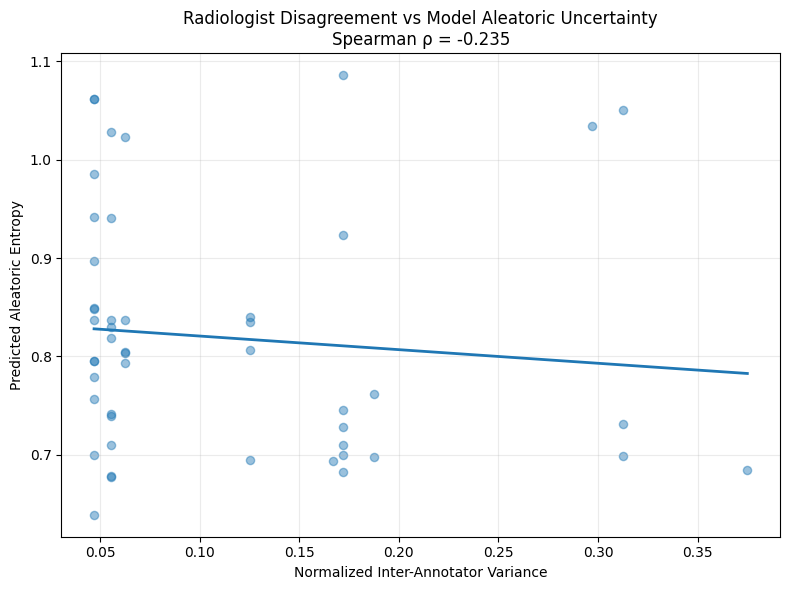

In [ ]:
#@title GRAPH 1 — Disagreement vs predicted aleatoric entropy
# ============================================================
# GRAPH 1 — Disagreement vs predicted aleatoric entropy
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.45,
    s=35
)

# Simple linear trend for visualisation only
coef = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
yy = np.polyval(coef, xx)

plt.plot(xx, yy, linewidth=2)

plt.xlabel("Normalized Inter-Annotator Variance")
plt.ylabel("Predicted Aleatoric Entropy")

plt.title(
    "Radiologist Disagreement vs Model Aleatoric Uncertainty\n"
    f"Spearman ρ = {rho:.3f}"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
#@title TABLE 2 — Calibration / classification trade-off
# ============================================================
# TABLE 2 — Calibration / classification trade-off
# Replace values with actual 5-fold means.
# ============================================================

tradeoff_table = pd.DataFrame({
    "Model": [
        "B1",
        "B2",
        "B3",
        "B4",
        "C1",
        "C2"
    ],
    "F1_Macro": [
        np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan
    ],
    "AUROC": [
        np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan
    ],
    "Brier": [
        np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan
    ],
    "ECE": [
        np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan
    ]
})

display(tradeoff_table)

,Model,F1_Macro,AUROC,Brier,ECE
0,B1,NaN,NaN,NaN,NaN
1,B2,NaN,NaN,NaN,NaN
2,B3,NaN,NaN,NaN,NaN
3,B4,NaN,NaN,NaN,NaN
4,C1,NaN,NaN,NaN,NaN
5,C2,NaN,NaN,NaN,NaN
